# 07. OOS metrics summary (AutoIntent + AutoML)

Сводный анализ метрик из **`tasks/oos_detection/results/metrics.json`** (тот же набор, что в эталонном `metrics_clean_legacy_plus_lama13.json`): бейзлайны, AutoIntent, LaMA / H2O / AutoGluon на CLINC150 OOS.

## Содержание
1. Setup
2. Обзор данных
3. Full train по источникам (standard / deeppavlov)
4. Few-shot (mean ± std по числу прогонов)
5. Scaling curve (F1 OOS vs объём обучения)
6. F1 OOS vs latency (Pareto-вид)
7. Краткие выводы

## 1. Setup

In [1]:
# Load environment variables from .env (опционально)
from pathlib import Path
try:
    from dotenv import load_dotenv
    load_dotenv("../../../.env")
except Exception:
    pass

import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
TASK_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_DIR.parent.parent
RESULTS = TASK_DIR / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
METRICS_PATH = RESULTS / "metrics.json"

if not METRICS_PATH.exists():
    raise FileNotFoundError(f"Нет файла: {METRICS_PATH}")

metrics_all = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
df = pd.DataFrame(metrics_all)


def extra_get(row, key, default=None):
    ex = row.get("extra")
    if isinstance(ex, dict):
        return ex.get(key, default)
    return default


df["source"] = df.apply(lambda r: extra_get(r, "source", "unknown"), axis=1)
df["framework"] = df.apply(lambda r: extra_get(r, "framework"), axis=1)


def model_family(name: str) -> str:
    n = str(name).lower()
    if "autointent" in n:
        return "autointent"
    if "lama" in n:
        return "lama"
    if "h2o" in n:
        return "h2o"
    if "autogluon" in n:
        return "autogluon"
    if "cosine" in n:
        return "cosine"
    if "tfidf" in n:
        return "tfidf"
    return "other"


df["family"] = df["model_name"].map(model_family)
df["framework"] = df["framework"].fillna(
    df["family"].where(df["family"].isin(["lama", "h2o", "autogluon"]))
)

MODELS_ORDER = [
    "autointent_classic-light",
    "autointent_classic-light_autoembedder",
    "lama_threshold",
    "h2o_threshold",
    "autogluon_threshold",
    "cosine_e5large_threshold",
    "cosine_minilm_threshold",
    "cosine_bert_threshold",
    "tfidf_threshold",
]

df_full = df[(df["mode"] == "full") & (df["model_name"].isin(MODELS_ORDER))].copy()

print(f"Файл: {METRICS_PATH}")
print(f"Строк: {len(df)} | Моделей: {df['model_name'].nunique()} | Sources: {df['source'].unique().tolist()}")


Файл: /Users/oleguzov/Desktop/lab_mipt/second_testing/metrics_clean_legacy_plus_lama13.json
Строк: 254 | Моделей: 13 | Sources: ['standard', 'deeppavlov']


## 2. Обзор данных

In [2]:
print("=== Записей по source ===")
display(df.groupby("source").size().to_frame("n"))

print("\n=== Записей по mode ===")
display(df.groupby("mode").size().to_frame("n"))

print("\n=== Семейства моделей (по family) ===")
display(df.groupby("family").size().sort_values(ascending=False).to_frame("n"))


=== Записей по source ===


,n
source,
deeppavlov,123
standard,131



=== Записей по mode ===


,n
mode,
10shot,78
20shot,75
50shot,75
full,26



=== Семейства моделей (по family) ===


,n
family,
cosine,120
autointent,40
tfidf,40
autogluon,20
h2o,20
lama,14


## 3. Full train по источникам

In [3]:
for source in ["deeppavlov", "standard"]:
    sub = df_full[df_full["source"] == source].copy()
    if sub.empty:
        print(f"--- {source.upper()} — нет строк full train для выбранных моделей ---\n")
        continue
    sub["_ord"] = sub["model_name"].apply(
        lambda x: MODELS_ORDER.index(x) if x in MODELS_ORDER else 99
    )
    sub = sub.sort_values("_ord")
    cols = ["model_name", "oos_recall", "in_domain_acc", "f1_oos", "auroc", "au_ioc", "latency_ms"]
    table = sub[cols].copy()
    table.columns = ["Model", "OOS Recall", "In-D Acc", "F1 OOS", "AUROC", "AU-IoC", "Lat(ms)"]
    for c in ["OOS Recall", "In-D Acc", "F1 OOS", "AUROC", "AU-IoC"]:
        table[c] = table[c].map(lambda x: f"{x:.3f}")
    table["Lat(ms)"] = table["Lat(ms)"].map(lambda x: f"{x:.2f}")
    print(f"=== FULL TRAIN — {source.upper()} ===")
    display(table)
    print()


=== FULL TRAIN — DEEPPAVLOV ===


,Model,OOS Recall,In-D Acc,F1 OOS,AUROC,AU-IoC,Lat(ms)
170,autointent_classic-light,0.562,0.959,0.703,0.974,0.941,28.49
190,autointent_classic-light_autoembedder,0.562,0.959,0.703,0.974,0.941,0.12
251,lama_threshold,nan,nan,0.699,0.969,nan,nan
225,h2o_threshold,0.568,0.967,0.703,0.970,0.000,1527.17
212,autogluon_threshold,0.552,0.928,0.624,0.934,0.850,242.98
87,cosine_e5large_threshold,0.599,0.907,0.722,0.961,0.882,19.25
85,cosine_minilm_threshold,0.500,0.874,0.647,0.963,0.854,6.99
83,cosine_bert_threshold,0.292,0.824,0.421,0.898,0.766,17.51
81,tfidf_threshold,0.284,0.876,0.408,0.874,0.789,2.92



=== FULL TRAIN — STANDARD ===


,Model,OOS Recall,In-D Acc,F1 OOS,AUROC,AU-IoC,Lat(ms)
160,autointent_classic-light,0.557,0.958,0.699,0.973,0.940,0.20
180,autointent_classic-light_autoembedder,0.557,0.958,0.699,0.973,0.940,0.18
241,lama_threshold,nan,nan,0.575,0.968,nan,nan
222,h2o_threshold,0.571,0.967,0.706,0.968,0.942,1932.95
203,autogluon_threshold,0.673,0.920,0.688,0.934,0.826,250.42
7,cosine_e5large_threshold,0.599,0.907,0.722,0.961,0.882,18.98
5,cosine_minilm_threshold,0.500,0.874,0.647,0.963,0.854,6.98
3,cosine_bert_threshold,0.292,0.824,0.421,0.898,0.766,14.31
1,tfidf_threshold,0.322,0.873,0.448,0.872,0.781,3.06


## 4. Few-shot: F1 OOS (mean ± std)

In [4]:
n_shots_values = sorted(df[df["n_shots"].notna()]["n_shots"].astype(int).unique())

summary_rows = []
for source in ["deeppavlov", "standard"]:
    dsrc = df[df["source"] == source]
    for model in MODELS_ORDER:
        row = {"source": source, "model": model}
        for n in n_shots_values:
            part = dsrc[(dsrc["model_name"] == model) & (dsrc["n_shots"] == n)]
            if len(part) == 0:
                row[f"{n}-shot"] = "—"
            else:
                m, s = part["f1_oos"].mean(), part["f1_oos"].std(ddof=0)
                if len(part) > 1 and s > 1e-9:
                    row[f"{n}-shot"] = f"{m:.3f} ± {s:.3f}"
                else:
                    row[f"{n}-shot"] = f"{m:.3f}"
        summary_rows.append(pd.Series(row))
fewshot_summary = pd.DataFrame(summary_rows)
print("Few-shot F1 OOS по source (колонки — n_shots)")
display(fewshot_summary)


Few-shot F1 OOS по source (колонки — n_shots)


,source,model,10-shot,20-shot,50-shot
0,deeppavlov,autointent_classic-light,0.763 ± 0.014,0.790 ± 0.024,0.732 ± 0.002
1,deeppavlov,autointent_classic-light_autoembedder,0.763 ± 0.014,0.790 ± 0.024,0.732 ± 0.002
2,deeppavlov,lama_threshold,0.673 ± 0.010,—,—
3,deeppavlov,h2o_threshold,0.631 ± 0.031,0.747 ± 0.030,0.745 ± 0.020
4,deeppavlov,autogluon_threshold,0.715 ± 0.033,0.677 ± 0.036,0.699 ± 0.069
5,deeppavlov,cosine_e5large_threshold,0.651 ± 0.025,0.694 ± 0.028,0.654 ± 0.023
6,deeppavlov,cosine_minilm_threshold,0.662 ± 0.020,0.638 ± 0.032,0.685 ± 0.006
7,deeppavlov,cosine_bert_threshold,0.403 ± 0.034,0.398 ± 0.028,0.388 ± 0.029
8,deeppavlov,tfidf_threshold,0.257 ± 0.008,0.242 ± 0.053,0.347 ± 0.015
9,standard,autointent_classic-light,0.722 ± 0.036,0.742 ± 0.065,0.725 ± 0.011


## 5. Scaling curve (выбранные модели)

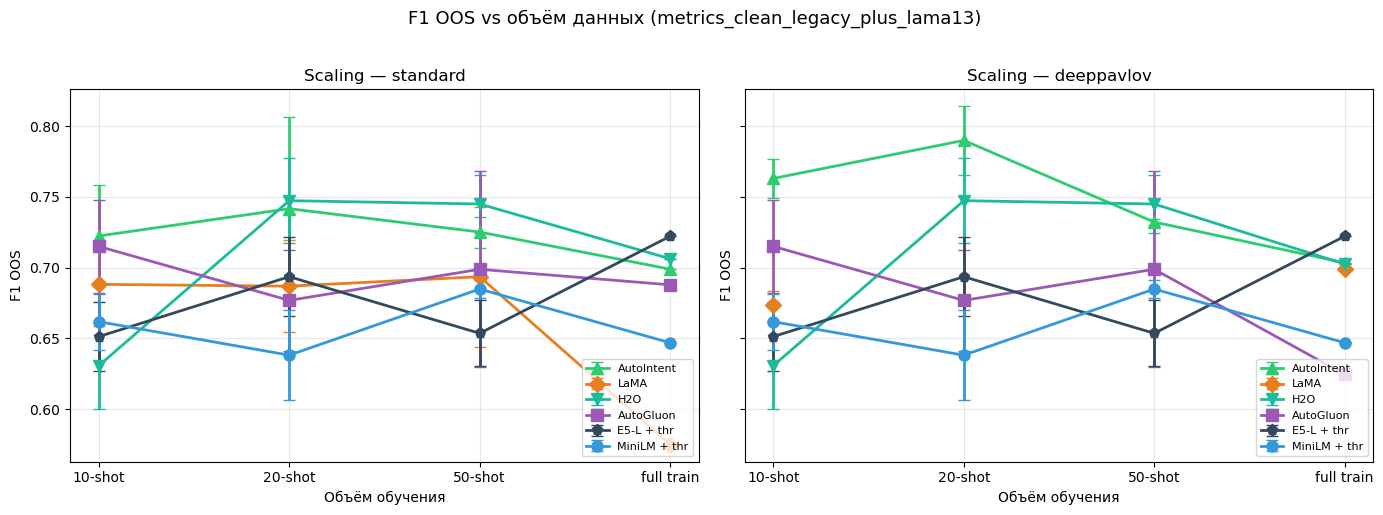

Saved: /Users/oleguzov/Desktop/lab_mipt/second_testing/tasks/oos_detection/results/07_scaling_legacy_plus_lama13.png


In [5]:
scaling_models = [
    "autointent_classic-light",
    "lama_threshold",
    "h2o_threshold",
    "autogluon_threshold",
    "cosine_e5large_threshold",
    "cosine_minilm_threshold",
]

x_labels = ["10-shot", "20-shot", "50-shot", "full train"]


def collect_scaling(source: str):
    rows = []
    dsrc = df[df["source"] == source]
    for model in scaling_models:
        mdf = dsrc[dsrc["model_name"] == model]
        for n in [10, 20, 50]:
            sub = mdf[mdf["n_shots"] == n]
            if len(sub):
                rows.append({
                    "model": model,
                    "mode": f"{n}-shot",
                    "f1_mean": sub["f1_oos"].mean(),
                    "f1_std": sub["f1_oos"].std(ddof=0) if len(sub) > 1 else 0.0,
                })
        full = mdf[mdf["mode"] == "full"]
        if len(full):
            rows.append({
                "model": model,
                "mode": "full train",
                "f1_mean": full["f1_oos"].iloc[0],
                "f1_std": 0.0,
            })
    return pd.DataFrame(rows)

scaling_std = collect_scaling("standard")
scaling_dp = collect_scaling("deeppavlov")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
styles = {
    "autointent_classic-light": ("#2ecc71", "^", "AutoIntent"),
    "lama_threshold": ("#e67e22", "D", "LaMA"),
    "h2o_threshold": ("#1abc9c", "v", "H2O"),
    "autogluon_threshold": ("#9b59b6", "s", "AutoGluon"),
    "cosine_e5large_threshold": ("#34495e", "p", "E5-L + thr"),
    "cosine_minilm_threshold": ("#3498db", "o", "MiniLM + thr"),
}
x_pos = np.arange(len(x_labels))

for ax, scaling_df, title in [
    (axes[0], scaling_std, "standard"),
    (axes[1], scaling_dp, "deeppavlov"),
]:
    for model in scaling_models:
        color, marker, label = styles[model]
        y = []
        err = []
        for mode in x_labels:
            r = scaling_df[(scaling_df["model"] == model) & (scaling_df["mode"] == mode)]
            if len(r):
                y.append(r["f1_mean"].values[0])
                err.append(r["f1_std"].values[0])
            else:
                y.append(np.nan)
                err.append(0.0)
        ax.errorbar(
            x_pos, y, yerr=err, marker=marker, color=color, linewidth=2, capsize=4,
            label=label, markersize=8,
        )
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Объём обучения")
    ax.set_ylabel("F1 OOS")
    ax.set_title(f"Scaling — {title}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)

plt.suptitle("F1 OOS vs объём данных (results/metrics.json)", fontsize=13, y=1.02)
plt.tight_layout()
out = RESULTS / "07_scaling_metrics.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out)


## 6. F1 OOS vs latency (full train)

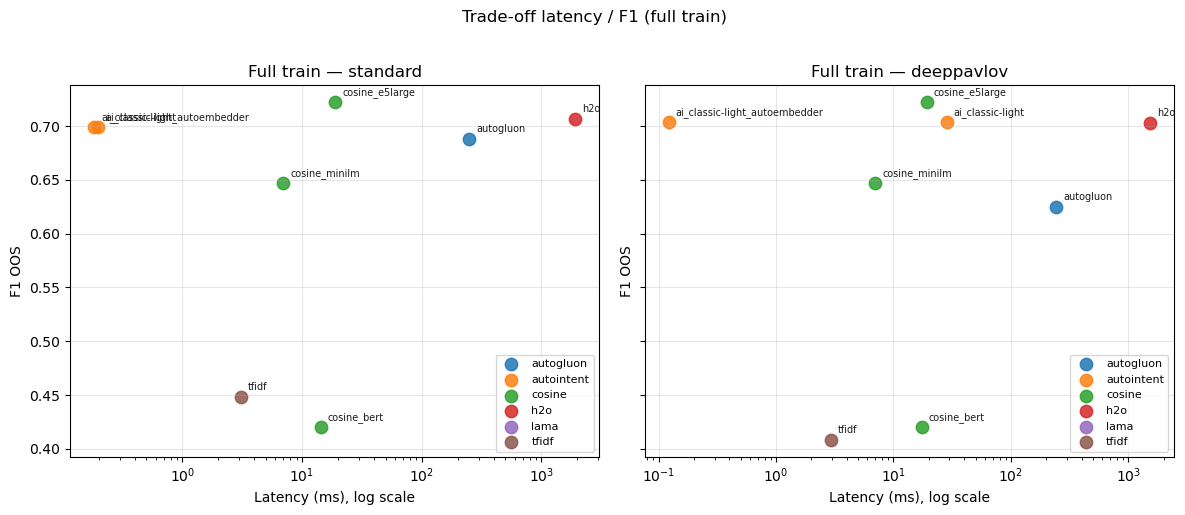

Saved: /Users/oleguzov/Desktop/lab_mipt/second_testing/tasks/oos_detection/results/07_f1_vs_latency_legacy_plus_lama13.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, source in zip(axes, ["standard", "deeppavlov"]):
    sub = df_full[df_full["source"] == source]
    for fam, g in sub.groupby("family"):
        ax.scatter(
            g["latency_ms"], g["f1_oos"],
            s=80, alpha=0.85, label=fam,
        )
        for _, r in g.iterrows():
            ax.annotate(
                r["model_name"].replace("_threshold", "").replace("autointent_", "ai_"),
                (r["latency_ms"], r["f1_oos"]),
                fontsize=7, alpha=0.9,
                xytext=(5, 5), textcoords="offset points",
            )
    ax.set_xscale("log")
    ax.set_xlabel("Latency (ms), log scale")
    ax.set_ylabel("F1 OOS")
    ax.set_title(f"Full train — {source}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Trade-off latency / F1 (full train)", y=1.02)
plt.tight_layout()
out2 = RESULTS / "07_f1_vs_latency_metrics.png"
plt.savefig(out2, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out2)


## 7. Краткие выводы

- Данные: **`tasks/oos_detection/results/metrics.json`** (эталонный набор совпадает с `metrics_clean_legacy_plus_lama13.json` в корне — при обновлении любого из них синхронизируйте при необходимости и перезапустите ноутбук).
- Сравнивайте **standard** vs **deeppavlov** отдельно: различается состав train (в т.ч. число OOS в обучении).
- Блок AutoML (**LaMA**, **H2O**, **AutoGluon**) дополняет **AutoIntent** и embedding-бейзлайны; latency у тяжёлых фреймворков обычно выше — см. раздел 6.
